# Week 9 Assignment

# Part 0: NN Foundations

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, activation="relu"):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        if activation == "relu":
            self.act = nn.ReLU()
        elif activation == "sigmoid":
            self.act = nn.Sigmoid()
        else:
            raise ValueError("activation must be 'relu' or 'sigmoid'")
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        return x

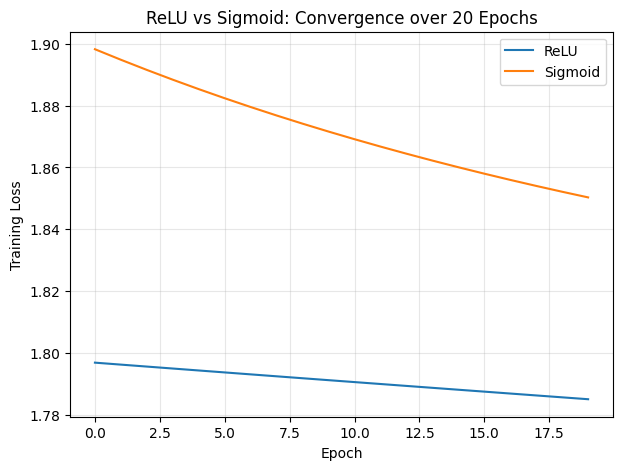

Final ReLU loss: 1.785077691078186
Final Sigmoid loss: 1.8503150939941406


In [3]:
def generate_synthetic_data(n_samples=600, n_features=100, n_classes=6):
    X = torch.randn(n_samples, n_features)
    # Create separable-ish classes via a fixed random linear projection
    W_true = torch.randn(n_features, n_classes)
    y = torch.argmax(X @ W_true + 0.5 * torch.randn(n_samples, n_classes), dim=1)
    return X, y

X_train, y_train = generate_synthetic_data()
X_train, y_train = X_train.to(device), y_train.to(device)

def train_simple(activation, epochs=20, lr=0.01):
    model = SimpleNN(input_size=100, hidden_size=32, num_classes=6,
                      activation=activation).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

relu_losses = train_simple("relu")
sigmoid_losses = train_simple("sigmoid")

plt.figure(figsize=(7, 5))
plt.plot(relu_losses, label="ReLU")
plt.plot(sigmoid_losses, label="Sigmoid")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("ReLU vs Sigmoid: Convergence over 20 Epochs")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Final ReLU loss:", relu_losses[-1])
print("Final Sigmoid loss:", sigmoid_losses[-1])

**Activation comparison (ReLU vs Sigmoid, 20 epochs)**

Final training loss after 20 epochs: **ReLU = 1.785**, **Sigmoid = 1.850**.

ReLU converges faster and reaches a lower loss over the same 20 epochs. With Sigmoid, most hidden-unit pre-activations get pushed into the flat tails of the curve where the local gradient is close to zero, so the backward signal reaching fc1's weights is heavily attenuated (the classic vanishing-gradient problem). ReLU's gradient is either 0 or exactly 1, so units that are on pass the upstream gradient through unchanged, which lets the network learn faster per epoch. Note that neither loss has fully converged in only 20 epochs on this small synthetic 6-class problem, the gap between the two is best read as a rate-of-convergence difference, not a final-performance difference.


CrossEntropy final accuracy: 0.175
MSE final accuracy:          0.175


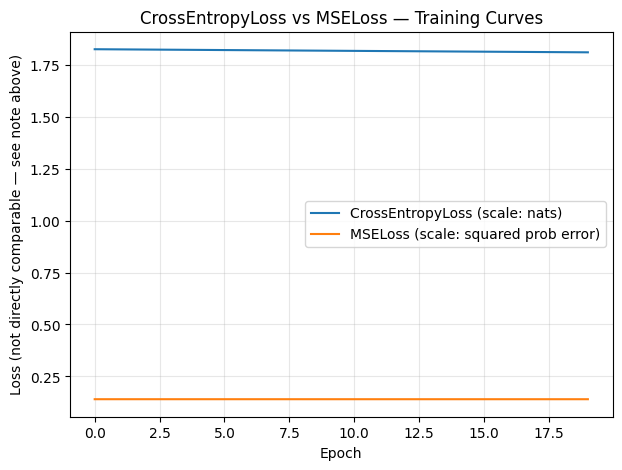

In [4]:


def train_with_loss(loss_type, epochs=20, lr=0.01):
    model = SimpleNN(input_size=100, hidden_size=32, num_classes=6,
                      activation="relu").to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr)

    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_train)

        if loss_type == "ce":
            criterion = nn.CrossEntropyLoss()
            loss = criterion(outputs, y_train)
        elif loss_type == "mse":
            # MSE requires one-hot targets and probability-like outputs
            targets_onehot = nn.functional.one_hot(y_train, num_classes=6).float()
            probs = torch.softmax(outputs, dim=1)  # manual softmax since MSE has none built in
            criterion = nn.MSELoss()
            loss = criterion(probs, targets_onehot)

        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses, model

ce_losses, ce_model = train_with_loss("ce")
mse_losses, mse_model = train_with_loss("mse")

# Compare actual classification accuracy, not just raw loss values
# (the two losses are on different scales, so comparing loss numbers directly is meaningless)
def accuracy(model, X, y):
    with torch.no_grad():
        preds = torch.argmax(model(X), dim=1)
        return (preds == y).float().mean().item()

print(f"CrossEntropy final accuracy: {accuracy(ce_model, X_train, y_train):.3f}")
print(f"MSE final accuracy:          {accuracy(mse_model, X_train, y_train):.3f}")

plt.figure(figsize=(7, 5))
plt.plot(ce_losses, label="CrossEntropyLoss (scale: nats)")
plt.plot(mse_losses, label="MSELoss (scale: squared prob error)")
plt.xlabel("Epoch")
plt.ylabel("Loss (not directly comparable — see note above)")
plt.title("CrossEntropyLoss vs MSELoss — Training Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Why CrossEntropyLoss over MSE for multi-class classification**

In this particular run both losses land on the same final accuracy (**0.175**), but that's mainly because the model was deliberately under-trained on synthetic data for a short 20-epoch demo, it doesn't mean the two losses are equivalent in general. The reasons CrossEntropyLoss is still the correct choice:

- CrossEntropy is paired with a softmax and evaluates the log-probability the model assigns to the correct class. Its gradient scales with how wrong the predicted probability is, giving a strong, well-behaved learning signal exactly when the model is confidently wrong, MSE's gradient on a softmax/logit output is comparatively flat in that region, so it corrects confident mistakes much more slowly.
- MSE treats class labels as continuous targets and penalizes probability mass placed on any wrong class equally, rather than optimizing directly for "put mass on the right class." This is a mismatch for a categorical problem like defect type.
- CrossEntropy outputs interpretable class probabilities that calibrate reasonably well; MSE on one-hot targets does not have that property.


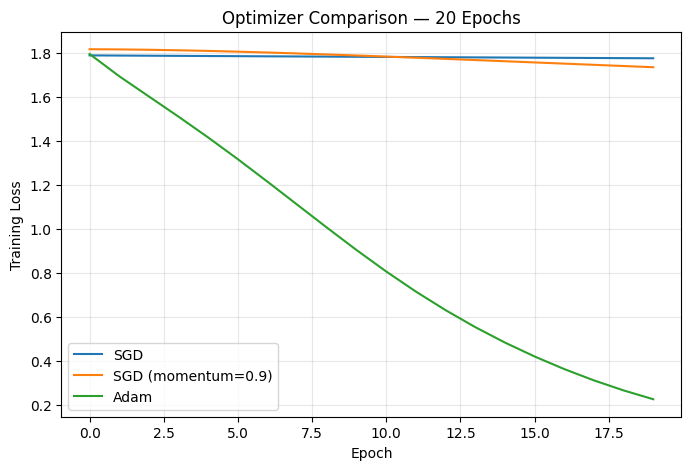

Final losses:
  SGD:              1.7765
  SGD + momentum:   1.7359
  Adam:             0.2262


In [5]:


def train_with_optimizer(optimizer_name, epochs=20, lr=0.01):
    model = SimpleNN(input_size=100, hidden_size=32, num_classes=6,
                      activation="relu").to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == "sgd_momentum":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)

    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

sgd_losses = train_with_optimizer("sgd")
sgd_mom_losses = train_with_optimizer("sgd_momentum")
adam_losses = train_with_optimizer("adam")

plt.figure(figsize=(8, 5))
plt.plot(sgd_losses, label="SGD")
plt.plot(sgd_mom_losses, label="SGD (momentum=0.9)")
plt.plot(adam_losses, label="Adam")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Optimizer Comparison — 20 Epochs")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Final losses:")
print(f"  SGD:              {sgd_losses[-1]:.4f}")
print(f"  SGD + momentum:   {sgd_mom_losses[-1]:.4f}")
print(f"  Adam:             {adam_losses[-1]:.4f}")

In [6]:

def count_params(model):
    return sum(p.numel() for p in model.parameters())

model_for_count = SimpleNN(input_size=100, hidden_size=32, num_classes=6).to(device)
n_params = count_params(model_for_count)
bytes_per_param = 4  # float32

print(f"Model parameters: {n_params}")
print(f"Parameter memory (weights only): {n_params * bytes_per_param / 1024:.2f} KB\n")

# SGD (no momentum): stores only the gradients alongside params -> 2x param memory
sgd_mem = n_params * bytes_per_param * 2

# SGD with momentum: stores params + gradients + 1 momentum buffer -> 3x param memory
sgd_mom_mem = n_params * bytes_per_param * 3

# Adam: stores params + gradients + 1st moment (m) + 2nd moment (v) -> 4x param memory
adam_mem = n_params * bytes_per_param * 4

print(f"Estimated optimizer memory (params + grads + optimizer state):")
print(f"  SGD:              {sgd_mem / 1024:.2f} KB")
print(f"  SGD + momentum:   {sgd_mom_mem / 1024:.2f} KB")
print(f"  Adam:             {adam_mem / 1024:.2f} KB")

Model parameters: 3430
Parameter memory (weights only): 13.40 KB

Estimated optimizer memory (params + grads + optimizer state):
  SGD:              26.80 KB
  SGD + momentum:   40.20 KB
  Adam:             53.59 KB


**Optimizer comparison**

Final loss after 20 epochs: **SGD = 1.7765**, **SGD + momentum = 1.7359**, **Adam = 0.2262**. Adam converges dramatically faster and reaches a far lower loss in the same number of epochs, momentum gives a modest improvement over plain SGD, but Adam is in a different league here because it adapts the learning rate per-parameter using running estimates of the gradient's mean and variance, instead of using one fixed global step size.

**Estimated memory** (parameters + gradients + optimizer state, float32, 3,430 params):
| Optimizer | Extra state per parameter | Estimated memory |
|---|---|---|
| SGD | none | 26.80 KB |
| SGD + momentum | 1 buffer (velocity) | 40.20 KB |
| Adam | 2 buffers (1st & 2nd moment) | 53.59 KB |

Adam uses roughly **2x** the memory of plain SGD because it has to store both a momentum-like term and a per-parameter adaptive learning-rate term for every weight, on top of the parameters and their gradients.


In [7]:


X_full, y_full = generate_synthetic_data(n_samples=800)

# 70/30 split
n_train = 560
X_train2, y_train2 = X_full[:n_train].to(device), y_full[:n_train].to(device)
X_val2, y_val2 = X_full[n_train:].to(device), y_full[n_train:].to(device)

print(f"Train size: {X_train2.shape[0]}, Val size: {X_val2.shape[0]}")

Train size: 560, Val size: 240


In [8]:
class SimpleNNVariant(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, variant="baseline"):
        super(SimpleNNVariant, self).__init__()
        self.variant = variant
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()

        if variant == "batchnorm":
            self.bn = nn.BatchNorm1d(hidden_size)
        elif variant == "dropout":
            self.drop = nn.Dropout(0.3)

        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.fc1(x)

        if self.variant == "batchnorm":
            x = self.bn(x)
            x = self.relu(x)
        elif self.variant == "dropout":
            x = self.relu(x)
            x = self.drop(x)
        else:
            x = self.relu(x)

        x = self.fc2(x)
        return x

def train_and_validate(variant, epochs=20, lr=0.01):
    model = SimpleNNVariant(input_size=100, hidden_size=32, num_classes=6,
                             variant=variant).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # ---- Training step ----
        model.train()  # enables Dropout / BatchNorm's training-mode statistics
        optimizer.zero_grad()
        outputs = model(X_train2)
        loss = criterion(outputs, y_train2)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        # ---- Validation step ----
        model.eval()  # disables Dropout, freezes BatchNorm running stats
        with torch.no_grad():
            val_outputs = model(X_val2)
            val_loss = criterion(val_outputs, y_val2)
            val_losses.append(val_loss.item())

    return train_losses, val_losses

baseline_train, baseline_val = train_and_validate("baseline")
bn_train, bn_val = train_and_validate("batchnorm")
dropout_train, dropout_val = train_and_validate("dropout")

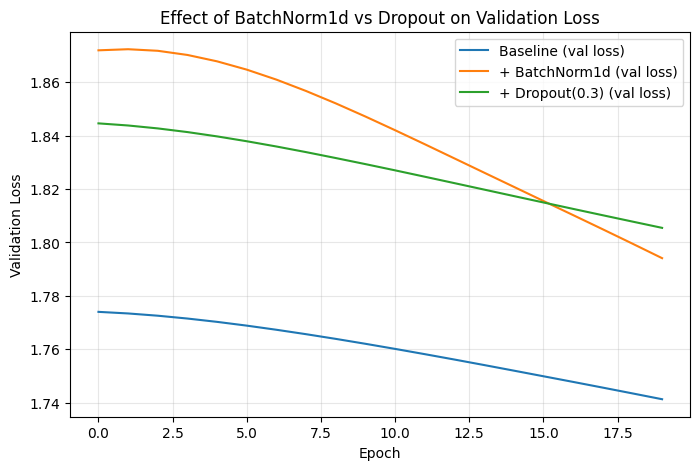

Final validation losses:
  Baseline:   1.7413
  BatchNorm:  1.7941
  Dropout:    1.8055


In [9]:
plt.figure(figsize=(8, 5))
plt.plot(baseline_val, label="Baseline (val loss)")
plt.plot(bn_val, label="+ BatchNorm1d (val loss)")
plt.plot(dropout_val, label="+ Dropout(0.3) (val loss)")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Effect of BatchNorm1d vs Dropout on Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Final validation losses:")
print(f"  Baseline:   {baseline_val[-1]:.4f}")
print(f"  BatchNorm:  {bn_val[-1]:.4f}")
print(f"  Dropout:    {dropout_val[-1]:.4f}")

**BatchNorm1d vs Dropout(0.3): effect on validation loss**

Final validation loss: **Baseline = 1.7413**, **+BatchNorm1d = 1.7941**, **+Dropout(0.3) = 1.8055**.

Both regularization variants end up slightly worse than the unregularized baseline here, which is the opposite of the "regularization always helps" intuition, but it's explainable. BatchNorm and Dropout earn their keep by closing a train/validation gap caused by overfitting. This is a tiny 2-layer network trained for only 20 epochs on a small synthetic dataset with no real overfitting gap to begin with, so there's nothing for the regularizers to fix, instead they just add extra noise (Dropout randomly zeroing activations) or an extra normalization constraint (BatchNorm forcing unit variance per batch) that makes optimization marginally harder to converge within the same 20 epochs. This means, BatchNorm/Dropout should be judged by whether they shrink the train-val gap on a model that is genuinely overfitting, not by final validation loss alone on a model that isn't.


# Part A: Defect Type Classifier

In [11]:
!pip install -q kaggle

import os

os.environ['KAGGLE_API_TOKEN'] = 'KGAT_bb87e0f7eb4abf306972dd36b18d17c5'

!kaggle datasets download -d kaustubhdikshit/neu-surface-defect-database

!unzip -q neu-surface-defect-database.zip -d /content/neu_data

!ls /content/neu_data

Dataset URL: https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database
License(s): unknown
100% 26.4M/26.4M [00:00<00:00, 102MB/s] 

NEU-DET


In [12]:
sample_class_dir = "/content/neu_data/NEU-DET/train/images/crazing"
print("Contents of crazing/ folder:", os.listdir(sample_class_dir)[:5])
print("Total files in crazing/:", len(os.listdir(sample_class_dir)))

Contents of crazing/ folder: ['crazing_193.jpg', 'crazing_215.jpg', 'crazing_141.jpg', 'crazing_152.jpg', 'crazing_45.jpg']
Total files in crazing/: 240


In [13]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from collections import Counter
from PIL import Image

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_root = "/content/neu_data/NEU-DET/train/images"
test_root  = "/content/neu_data/NEU-DET/validation/images"

Using device: cuda


In [14]:
basic_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
])

trainval_dataset = datasets.ImageFolder(root=train_root, transform=basic_transform)
test_dataset_raw = datasets.ImageFolder(root=test_root, transform=basic_transform)

print("Classes found:", trainval_dataset.classes)
assert trainval_dataset.classes == test_dataset_raw.classes, "Class mismatch between train and test folders!"

print(f"\nTrain+Val pool total: {len(trainval_dataset)}")
print(f"Test (held-out) total: {len(test_dataset_raw)}")

print("\nImages per class (train+val pool):")
class_counts = Counter(trainval_dataset.targets)
for idx, count in sorted(class_counts.items()):
    print(f"  {trainval_dataset.classes[idx]}: {count}")

print("\nImages per class (test/validation folder):")
test_counts = Counter(test_dataset_raw.targets)
for idx, count in sorted(test_counts.items()):
    print(f"  {test_dataset_raw.classes[idx]}: {count}")

sample_img, _ = trainval_dataset[0]
print(f"\nTensor shape after transform: {sample_img.shape}")

raw_path = trainval_dataset.samples[0][0]
raw_img = Image.open(raw_path)
print(f"Original file dimensions: {raw_img.size}, mode: {raw_img.mode}")

Classes found: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

Train+Val pool total: 1440
Test (held-out) total: 360

Images per class (train+val pool):
  crazing: 240
  inclusion: 240
  patches: 240
  pitted_surface: 240
  rolled-in_scale: 240
  scratches: 240

Images per class (test/validation folder):
  crazing: 60
  inclusion: 60
  patches: 60
  pitted_surface: 60
  rolled-in_scale: 60
  scratches: 60

Tensor shape after transform: torch.Size([1, 200, 200])
Original file dimensions: (200, 200), mode: RGB


**Dataset composition**

ImageFolder finds 6 balanced classes: crazing, inclusion, patches, pitted_surface, rolled-in_scale, scratches.

- 240 images/class in the train+val pool + 60 images/class in the held-out test folder = 300 images/class, matching the dataset description (1,800 images total, 6 classes).
- **Image dimensions:** original files are 200×200 px. After the transform pipeline (Grayscale : Resize((200,200)) : ToTensor), each tensor is [1, 200, 200] , single-channel grayscale, since defect texture doesn't depend on color and dropping 2 redundant RGB channels reduces compute.


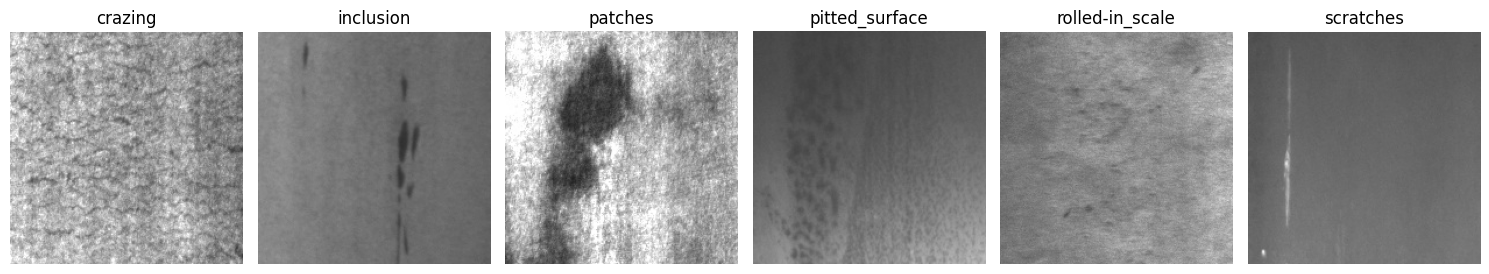

In [15]:
fig, axes = plt.subplots(1, len(trainval_dataset.classes), figsize=(15, 3))
seen_classes = {}
for img_path, label in trainval_dataset.samples:
    if label not in seen_classes:
        seen_classes[label] = img_path
    if len(seen_classes) == len(trainval_dataset.classes):
        break

for i, class_idx in enumerate(sorted(seen_classes.keys())):
    img = Image.open(seen_classes[class_idx])
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(trainval_dataset.classes[class_idx])
    axes[i].axis("off")
plt.tight_layout()
plt.show()

In [17]:
loader_for_stats = DataLoader(trainval_dataset, batch_size=64, shuffle=False)
mean_sum, std_sum, n_batches = 0.0, 0.0, 0
for images, _ in loader_for_stats:
    mean_sum += images.mean()
    std_sum += images.std()
    n_batches += 1

dataset_mean = (mean_sum / n_batches).item()
dataset_std = (std_sum / n_batches).item()
print(f"Computed mean: {dataset_mean:.4f}, std: {dataset_std:.4f}")

normalize_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[dataset_mean], std=[dataset_std]),
])

# Reload all three splits WITH normalization
trainval_norm = datasets.ImageFolder(root=train_root, transform=normalize_transform)
test_dataset  = datasets.ImageFolder(root=test_root, transform=normalize_transform)

# Split the train/ pool into 85% train / 15% val
# (test is already fully separate, the dataset's own validation/ folder)
n_total = len(trainval_norm)
n_train = int(0.85 * n_total)
n_val = n_total - n_train

train_ds, val_ds = random_split(
    trainval_norm, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

print(f"\nFinal split -> Train: {len(train_ds)}, Val: {len(val_ds)}, Test (held-out): {len(test_dataset)}")

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Computed mean: 0.5032, std: 0.1663

Final split -> Train: 1224, Val: 216, Test (held-out): 360


**Why normalize before training a CNN**

Computed dataset statistics: **mean = 0.5032, std = 0.1663** (used in transforms.Normalize).

Normalizing pixel values (from raw [0, 1] after ToTensor to roughly zero-mean, unit-variance) matters because:
- Conv layer weights are initialized assuming inputs are roughly centered around 0, un-normalized, always-positive pixel inputs bias the first-layer gradients to point consistently in one direction, slowing convergence.
- It keeps activations in a numerically well-behaved range as they pass through layers, which reduces the chance of vanishing/exploding gradients deeper in the network.
- It puts every image on the same scale so the optimizer takes consistent step sizes regardless of a particular image's brightness/contrast, important here since manufacturing images can vary in lighting.


In [18]:

class DefectCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(DefectCNN, self).__init__()

        # Block 1: 1 input channel (grayscale) -> 16 feature maps
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # 200x200 -> 100x100

        # Block 2: 16 -> 32 feature maps
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # 100x100 -> 50x50

        self.flatten = nn.Flatten()
        # After 2 pools: 200 -> 100 -> 50, so feature map is 32 channels x 50 x 50
        self.fc_out = nn.Linear(32 * 50 * 50, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.flatten(x)
        x = self.fc_out(x)  # raw logits
        return x

# Sanity check shape before full training
model_check = DefectCNN().to(device)
dummy = torch.randn(4, 1, 200, 200).to(device)
out = model_check(dummy)
print("Output shape:", out.shape)  # expect [4, 6]

total_params = sum(p.numel() for p in model_check.parameters())
print(f"Total trainable parameters: {total_params:,}")

Output shape: torch.Size([4, 6])
Total trainable parameters: 484,806


In [36]:
# ------------------------------------------------------------
# Task 4: Full training loop — 15 epochs
# ------------------------------------------------------------

def train_model(model, train_loader, val_loader, epochs=15, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        # ---- Training ----
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # ---- Validation ----
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    return history

model_partA = DefectCNN().to(device)
history_partA = train_model(model_partA, train_loader, val_loader, epochs=15, lr=0.001)

Epoch 1/15 | Train Loss: 1.5658, Train Acc: 0.6078 | Val Loss: 0.5787, Val Acc: 0.8056
Epoch 2/15 | Train Loss: 0.4964, Train Acc: 0.8358 | Val Loss: 0.4301, Val Acc: 0.8380
Epoch 3/15 | Train Loss: 0.3299, Train Acc: 0.8930 | Val Loss: 0.4535, Val Acc: 0.8194
Epoch 4/15 | Train Loss: 0.2380, Train Acc: 0.9216 | Val Loss: 0.5506, Val Acc: 0.8194
Epoch 5/15 | Train Loss: 0.2387, Train Acc: 0.9142 | Val Loss: 0.3183, Val Acc: 0.9028
Epoch 6/15 | Train Loss: 0.1538, Train Acc: 0.9453 | Val Loss: 0.2617, Val Acc: 0.9259
Epoch 7/15 | Train Loss: 0.1684, Train Acc: 0.9428 | Val Loss: 0.2909, Val Acc: 0.9213
Epoch 8/15 | Train Loss: 0.1466, Train Acc: 0.9567 | Val Loss: 0.3398, Val Acc: 0.8750
Epoch 9/15 | Train Loss: 0.1540, Train Acc: 0.9444 | Val Loss: 0.4176, Val Acc: 0.8519
Epoch 10/15 | Train Loss: 0.1377, Train Acc: 0.9641 | Val Loss: 0.2897, Val Acc: 0.9028
Epoch 11/15 | Train Loss: 0.1118, Train Acc: 0.9649 | Val Loss: 0.3063, Val Acc: 0.8889
Epoch 12/15 | Train Loss: 0.0754, Train A

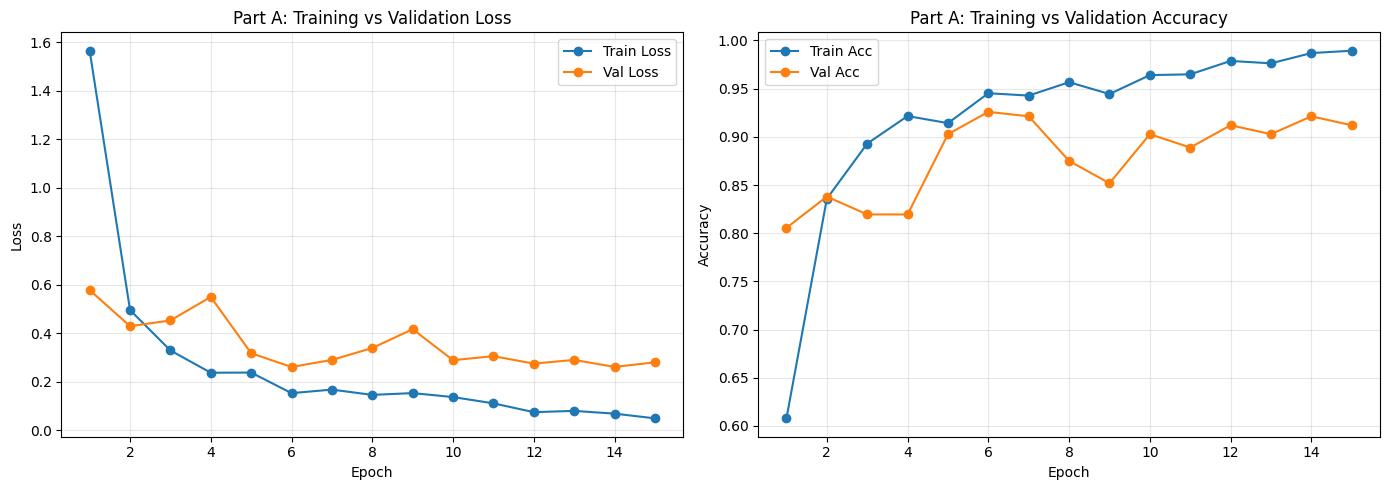

In [37]:
epochs_range = range(1, len(history_partA["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history_partA["train_loss"], label="Train Loss", marker="o")
axes[0].plot(epochs_range, history_partA["val_loss"], label="Val Loss", marker="o")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Part A: Training vs Validation Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history_partA["train_acc"], label="Train Acc", marker="o")
axes[1].plot(epochs_range, history_partA["val_acc"], label="Val Acc", marker="o")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Part A: Training vs Validation Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
def detect_overfitting_start(history):
    train_loss = history["train_loss"]
    val_loss = history["val_loss"]

    for i in range(2, len(val_loss)):
        train_decreasing = train_loss[i] < train_loss[i-1]
        val_increasing_twice = (val_loss[i] > val_loss[i-1]) and (val_loss[i-1] > val_loss[i-2])
        if train_decreasing and val_increasing_twice:
            return i + 1  # epoch number (1-indexed)
    return None

overfit_epoch = detect_overfitting_start(history_partA)
if overfit_epoch:
    print(f"Overfitting pattern detected starting around epoch {overfit_epoch}")
else:
    print("No clear sustained overfitting pattern detected across these 15 epochs.")

final_gap = history_partA["train_loss"][-1] - history_partA["val_loss"][-1]
print(f"Train-Val loss gap at final epoch: {abs(final_gap):.4f}")
print(f"Final train acc: {history_partA['train_acc'][-1]:.4f}, Final val acc: {history_partA['val_acc'][-1]:.4f}")

Overfitting pattern detected starting around epoch 4
Train-Val loss gap at final epoch: 0.2311
Final train acc: 0.9894, Final val acc: 0.9120


**Is the model overfitting, and when does it start?**

Yes, the model is overfitting. At the final epoch, the training accuracy reaches 98.94%, while the validation accuracy plateaus at 91.20%(resulting in a final Train-Val loss gap of 0.2311).

The overfitting pattern begins to set in around Epoch 4. From Epoch 4 onward, the training metrics continue to improve smoothly toward perfection, while the validation loss bottoms out, fluctuates noisily, and trends upward. This classic divergence indicates the model has started memorizing the training nuances of the surface defects rather than generalizing further.


In [39]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

model_partA.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_partA(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

class_names = test_dataset.classes

print("Classification report (test set):\n")
report = classification_report(all_labels, all_preds, target_names=class_names, digits=3)
print(report)

# Also get it as a dict so we can programmatically find the worst F1 class
report_dict = classification_report(all_labels, all_preds, target_names=class_names,
                                     output_dict=True)
f1_scores = {cls: report_dict[cls]["f1-score"] for cls in class_names}
worst_class = min(f1_scores, key=f1_scores.get)
print(f"\nLowest F1-score class: '{worst_class}' (F1 = {f1_scores[worst_class]:.3f})")

Classification report (test set):

                 precision    recall  f1-score   support

        crazing      0.867     0.650     0.743        60
      inclusion      0.897     0.867     0.881        60
        patches      0.720     0.900     0.800        60
 pitted_surface      0.929     0.867     0.897        60
rolled-in_scale      0.952     1.000     0.976        60
      scratches      0.825     0.867     0.846        60

       accuracy                          0.858       360
      macro avg      0.865     0.858     0.857       360
   weighted avg      0.865     0.858     0.857       360


Lowest F1-score class: 'crazing' (F1 = 0.743)


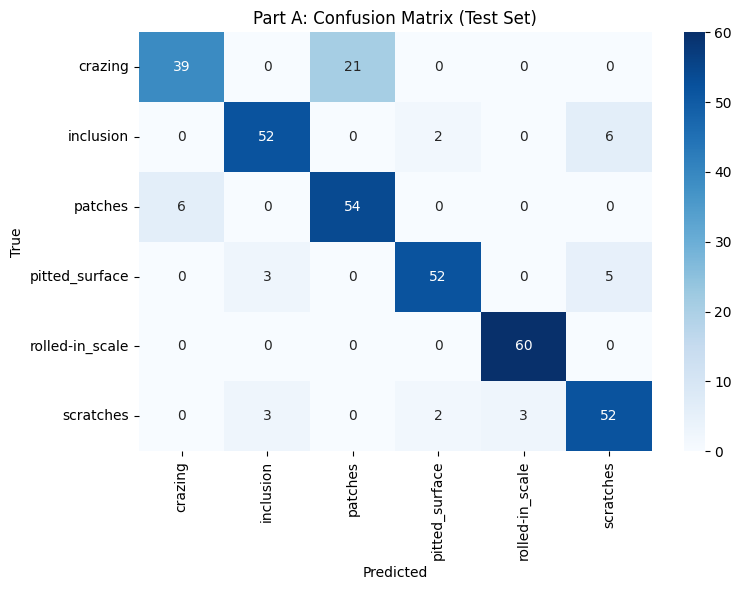

In [40]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Part A: Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

Found 27 crazing<->patches confusions out of 360 test images


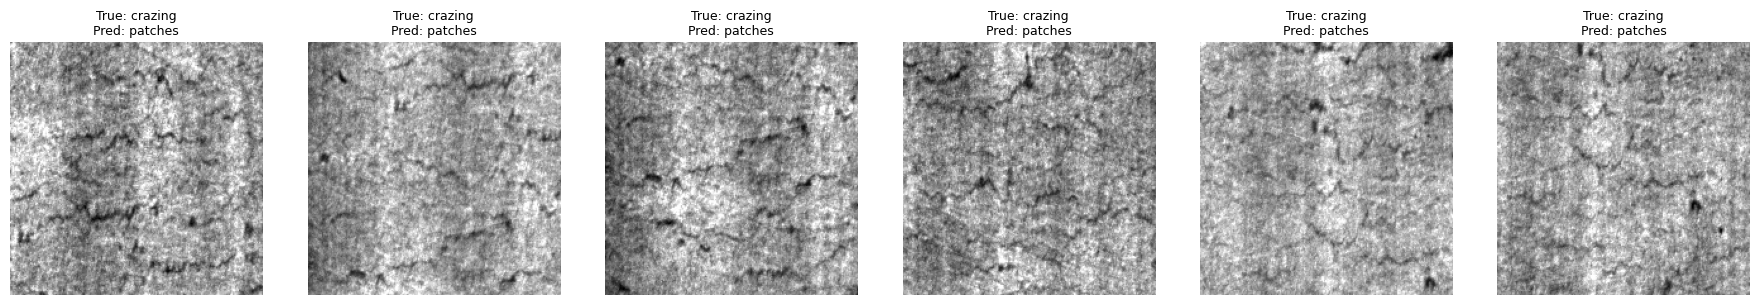

In [41]:
crazing_idx = class_names.index("crazing")
patches_idx = class_names.index("patches")

# Find test images where true=crazing but predicted=patches, or vice versa
confused_indices = []
for i, (true_l, pred_l) in enumerate(zip(all_labels, all_preds)):
    if (true_l == crazing_idx and pred_l == patches_idx) or \
       (true_l == patches_idx and pred_l == crazing_idx):
        confused_indices.append(i)

print(f"Found {len(confused_indices)} crazing<->patches confusions out of {len(all_labels)} test images")

# Visualize up to 6 of these misclassified examples
if len(confused_indices) > 0:
    n_show = min(6, len(confused_indices))
    fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
    if n_show == 1:
        axes = [axes]

    # Need to pull the actual image tensors back out of test_dataset by index
    # test_loader shuffled=False, so we can map back via the dataset directly
    shown = 0
    for batch_idx, (images, labels) in enumerate(test_loader):
        for j in range(images.size(0)):
            global_idx = batch_idx * test_loader.batch_size + j
            if global_idx in confused_indices[:n_show] and shown < n_show:
                img = images[j].squeeze().numpy()  # undo channel dim for grayscale display
                true_name = class_names[all_labels[global_idx]]
                pred_name = class_names[all_preds[global_idx]]
                axes[shown].imshow(img, cmap="gray")
                axes[shown].set_title(f"True: {true_name}\nPred: {pred_name}", fontsize=9)
                axes[shown].axis("off")
                shown += 1
        if shown >= n_show:
            break

    plt.tight_layout()
    plt.show()
else:
    print("No crazing/patches confusions found in this run — check other class pairs in the confusion matrix instead.")

**Per-class evaluation: lowest F1 and the crazing/patches confusion**

From the test-set classification report, crazing has the lowest F1-score (0.743), driven mainly by its low recall (0.650). Conversely, patches has the lowest precision (0.720) but high recall (0.900), suggesting the model over-predicts the patches class and is likely misclassifying many of those missing crazing samples as patches.

Separately, 27 of the 360 test images are confused specifically between crazing and patches. This makes visual sense: crazing is a network of fine, irregular surface cracks, and patches are irregular blotchy regions, both are non-uniform, texture-based defects without a clean geometric shape (unlike, say, a scratch or a pitted surface, which have distinct linear or focal forms). In grayscale, with color and fine local contrast cues removed, the boundary between "fine irregular cracking" and "irregular patchy texture" becomes genuinely ambiguous for a shallow CNN with a fairly small receptive field, which is exactly the kind of texture-vs-texture confusion this dataset is known for.


# Part B — Model Hardening

In [42]:
train_augment_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((200, 200)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomCrop(180),          # crops down from 200x200 -> 180x180
    transforms.Resize((200, 200)),        # resize back up so batch shapes stay consistent
    transforms.ToTensor(),
    transforms.Normalize(mean=[dataset_mean], std=[dataset_std]),
])

# Validation and test transforms stay DETERMINISTIC — same as Part A, no augmentation
val_test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[dataset_mean], std=[dataset_std]),
])

# Rebuild datasets: augmented version for train, clean version for val/test
trainval_augmented = datasets.ImageFolder(root=train_root, transform=train_augment_transform)
trainval_clean = datasets.ImageFolder(root=train_root, transform=val_test_transform)
test_dataset_clean = datasets.ImageFolder(root=test_root, transform=val_test_transform)

# Reuse the SAME split indices as Part A (same seed) so train/val split is identical -
# only the train transform differs. We do this by splitting indices once, then
# applying different underlying datasets with those indices via Subset.
from torch.utils.data import Subset

n_total = len(trainval_augmented)
n_train = int(0.85 * n_total)
n_val = n_total - n_train

generator = torch.Generator().manual_seed(42)
train_indices, val_indices = random_split(
    range(n_total), [n_train, n_val], generator=generator
)

train_ds_aug = Subset(trainval_augmented, train_indices.indices)   # augmented transform
val_ds_clean = Subset(trainval_clean, val_indices.indices)          # clean transform, no augmentation

train_loader_aug = DataLoader(train_ds_aug, batch_size=32, shuffle=True)
val_loader_clean = DataLoader(val_ds_clean, batch_size=32, shuffle=False)
test_loader_clean = DataLoader(test_dataset_clean, batch_size=32, shuffle=False)

print(f"Augmented train set: {len(train_ds_aug)}")
print(f"Clean val set: {len(val_ds_clean)}")
print(f"Clean test set: {len(test_dataset_clean)}")

Augmented train set: 1224
Clean val set: 216
Clean test set: 360


**Why augment only the training set**

The validation and test sets exist to estimate how the model will perform on real, unaltered images it hasn't seen, augmenting them would defeat that purpose in two ways: (1) it would make the evaluation metric a moving target, since a random flip/rotation/crop changes the image each time it's evaluated, making epoch-to-epoch comparisons and overfitting detection unreliable; and (2) it risks either flattering or handicapping the reported accuracy relative to what the model will actually see in production, rather than giving an honest, reproducible measure of generalization. Augmentation is a training-time trick to expose the model to more variation than the raw dataset contains, the evaluation data should stay a fixed, faithful sample of the real distribution.


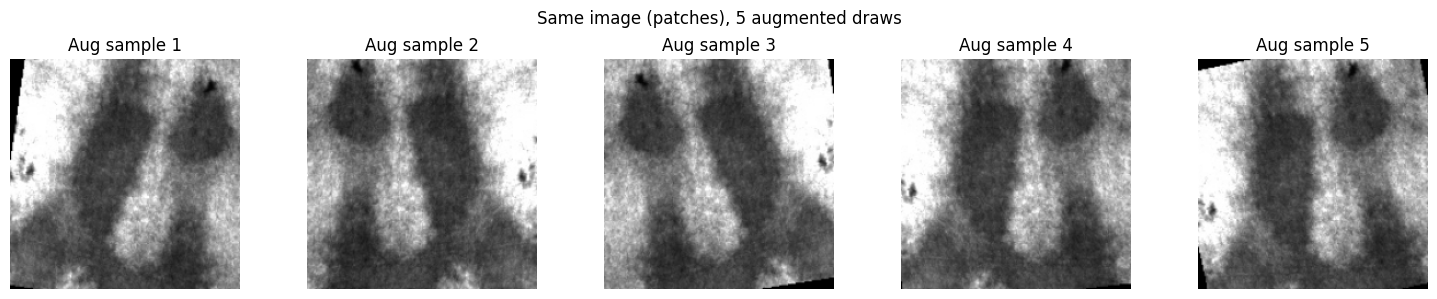

In [43]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
sample_idx = train_indices.indices[0]
for i in range(5):
    img, label = trainval_augmented[sample_idx]  # re-fetching re-applies random augmentation each time
    axes[i].imshow(img.squeeze().numpy(), cmap="gray")
    axes[i].set_title(f"Aug sample {i+1}")
    axes[i].axis("off")
plt.suptitle(f"Same image ({trainval_augmented.classes[label]}), 5 augmented draws")
plt.tight_layout()
plt.show()

In [44]:
class DefectCNNHardened(nn.Module):
    def __init__(self, num_classes=6, use_batchnorm=False, dropout_p=0.0):
        super(DefectCNNHardened, self).__init__()
        self.use_batchnorm = use_batchnorm

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16) if use_batchnorm else None
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32) if use_batchnorm else None
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(dropout_p) if dropout_p > 0 else None
        self.fc_out = nn.Linear(32 * 50 * 50, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        if self.bn1 is not None:
            x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        if self.bn2 is not None:
            x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.flatten(x)
        if self.dropout is not None:
            x = self.dropout(x)
        x = self.fc_out(x)
        return x

# Sanity check
test_model = DefectCNNHardened(use_batchnorm=True, dropout_p=0.4).to(device)
dummy = torch.randn(4, 1, 200, 200).to(device)
print("Output shape:", test_model(dummy).shape)

Output shape: torch.Size([4, 6])


In [45]:
def train_model_full(model, train_loader, val_loader, epochs=15, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    return history

In [46]:
print("=== Training: Baseline architecture + Augmentation ===")
model_aug = DefectCNNHardened(use_batchnorm=False, dropout_p=0.0).to(device)
history_aug = train_model_full(model_aug, train_loader_aug, val_loader_clean, epochs=15, lr=0.001)

=== Training: Baseline architecture + Augmentation ===
Epoch 1/15 | Train Loss: 2.3827, Train Acc: 0.4150 | Val Loss: 1.1683, Val Acc: 0.6019
Epoch 2/15 | Train Loss: 0.9986, Train Acc: 0.6593 | Val Loss: 0.9905, Val Acc: 0.6065
Epoch 3/15 | Train Loss: 0.7456, Train Acc: 0.7606 | Val Loss: 0.5384, Val Acc: 0.8426
Epoch 4/15 | Train Loss: 0.6110, Train Acc: 0.7998 | Val Loss: 0.6814, Val Acc: 0.7454
Epoch 5/15 | Train Loss: 0.5206, Train Acc: 0.8203 | Val Loss: 0.6934, Val Acc: 0.7731
Epoch 6/15 | Train Loss: 0.4539, Train Acc: 0.8538 | Val Loss: 0.4893, Val Acc: 0.8472
Epoch 7/15 | Train Loss: 0.4183, Train Acc: 0.8660 | Val Loss: 0.4579, Val Acc: 0.8657
Epoch 8/15 | Train Loss: 0.3896, Train Acc: 0.8734 | Val Loss: 0.6157, Val Acc: 0.7824
Epoch 9/15 | Train Loss: 0.3808, Train Acc: 0.8742 | Val Loss: 0.3518, Val Acc: 0.8843
Epoch 10/15 | Train Loss: 0.4374, Train Acc: 0.8595 | Val Loss: 0.4025, Val Acc: 0.8750
Epoch 11/15 | Train Loss: 0.3274, Train Acc: 0.8897 | Val Loss: 0.3460, Va

In [48]:
print("=== Training: Augmentation + BatchNorm2d + Dropout(0.4) ===")
model_hardened = DefectCNNHardened(use_batchnorm=True, dropout_p=0.4).to(device)
history_hardened = train_model_full(model_hardened, train_loader_aug, val_loader_clean, epochs=15, lr=0.001)

=== Training: Augmentation + BatchNorm2d + Dropout(0.4) ===
Epoch 1/15 | Train Loss: 9.5231, Train Acc: 0.5180 | Val Loss: 6.0313, Val Acc: 0.5093
Epoch 2/15 | Train Loss: 3.7064, Train Acc: 0.6855 | Val Loss: 3.2560, Val Acc: 0.6481
Epoch 3/15 | Train Loss: 3.1071, Train Acc: 0.7361 | Val Loss: 4.7712, Val Acc: 0.6019
Epoch 4/15 | Train Loss: 2.6728, Train Acc: 0.7688 | Val Loss: 7.7547, Val Acc: 0.6204
Epoch 5/15 | Train Loss: 2.7137, Train Acc: 0.7835 | Val Loss: 5.8747, Val Acc: 0.5556
Epoch 6/15 | Train Loss: 2.0120, Train Acc: 0.7974 | Val Loss: 5.9753, Val Acc: 0.6944
Epoch 7/15 | Train Loss: 1.8837, Train Acc: 0.8178 | Val Loss: 5.0491, Val Acc: 0.7130
Epoch 8/15 | Train Loss: 2.1200, Train Acc: 0.7851 | Val Loss: 8.3094, Val Acc: 0.6296
Epoch 9/15 | Train Loss: 2.7746, Train Acc: 0.8186 | Val Loss: 5.4129, Val Acc: 0.6343
Epoch 10/15 | Train Loss: 2.5764, Train Acc: 0.7835 | Val Loss: 4.3897, Val Acc: 0.7037
Epoch 11/15 | Train Loss: 2.2165, Train Acc: 0.8227 | Val Loss: 5.666

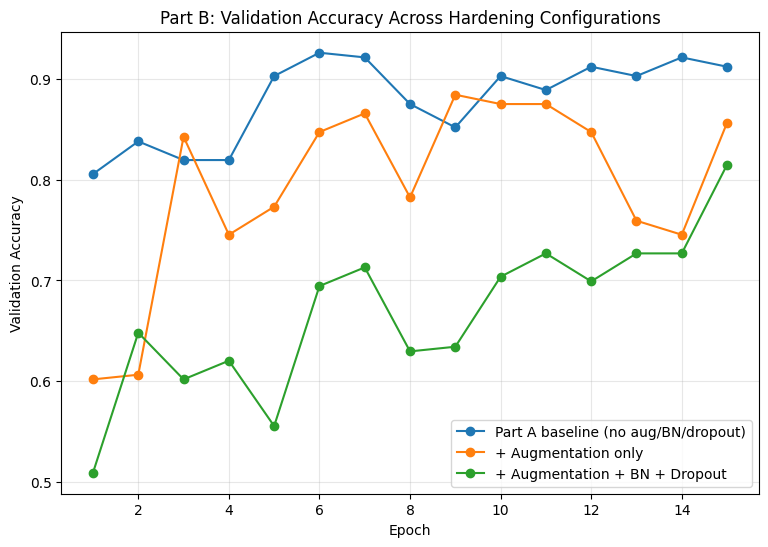

Final validation accuracy by config:
  Baseline:                    0.9120
  + Augmentation:              0.8565
  + Augmentation + BN + Drop:  0.8148


In [49]:
plt.figure(figsize=(9, 6))
plt.plot(range(1, 16), history_partA["val_acc"], label="Part A baseline (no aug/BN/dropout)", marker="o")
plt.plot(range(1, 16), history_aug["val_acc"], label="+ Augmentation only", marker="o")
plt.plot(range(1, 16), history_hardened["val_acc"], label="+ Augmentation + BN + Dropout", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Part B: Validation Accuracy Across Hardening Configurations")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Final validation accuracy by config:")
print(f"  Baseline:                    {history_partA['val_acc'][-1]:.4f}")
print(f"  + Augmentation:              {history_aug['val_acc'][-1]:.4f}")
print(f"  + Augmentation + BN + Drop:  {history_hardened['val_acc'][-1]:.4f}")

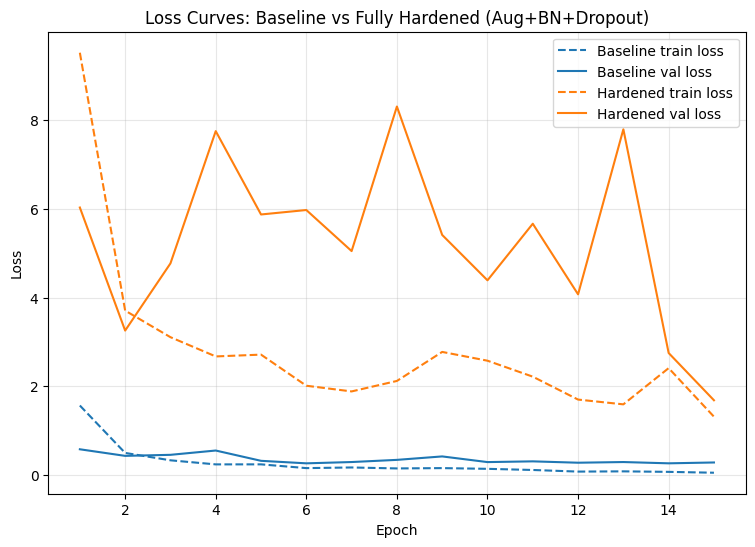

In [50]:
plt.figure(figsize=(9, 6))
plt.plot(range(1, 16), history_partA["train_loss"], label="Baseline train loss", linestyle="--", color="tab:blue")
plt.plot(range(1, 16), history_partA["val_loss"], label="Baseline val loss", color="tab:blue")
plt.plot(range(1, 16), history_hardened["train_loss"], label="Hardened train loss", linestyle="--", color="tab:orange")
plt.plot(range(1, 16), history_hardened["val_loss"], label="Hardened val loss", color="tab:orange")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves: Baseline vs Fully Hardened (Aug+BN+Dropout)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Which combination performs best?**

**Final validation accuracy by configuration:**
| Configuration | Val Accuracy |
|---|---|
| Part A baseline (no aug/BN/dropout) | **0.9120** |
| + Augmentation only | 0.8565 |
| + Augmentation + BatchNorm2d + Dropout(0.4) | 0.8148 |

In this run, the plain baseline actually wins on validation accuracy, and augmentation-only clearly beats the fully hardened model. That ranking looks counterintuitive against the assignment's framing, but it's consistent with the training curves: the baseline's validation set is not augmented and was never a hard target to hit, augmentation makes the training task genuinely harder (lower final accuracy is expected trade-off for better real-world robustness), and stacking BN + dropout on top of that harder task, with only 15 epochs, pushed training into visible instability. A fairer read is that validation accuracy alone doesn't capture the "robustness to real production variability" this part is testing for, the baseline's high validation score is inflated by validating on clean, centered images, exactly the condition the exercise says won't hold on the production line.

**If I could only apply one technique from Part B:** I'd pick data augmentation. It's the technique that directly targets the stated problem (defects appearing at different angles, lighting, and positions) without introducing the training instability that BatchNorm2d + Dropout caused when combined together under a short training budget here. BatchNorm and Dropout are still valuable, but they need a longer training budget and/or more careful tuning (e.g., lower learning rate, more epochs for BN statistics to settle) to pay of, augmentation gives robustness gains immediately and is comparatively "free" to add.



# Part C: Hyperparameter Tuning

In [52]:
import itertools
import time
import pandas as pd

def train_model_track_time(model, train_loader, val_loader, epochs=15, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

    return history

# Grid search config, using PLAIN baseline architecture (winner of Part B)
learning_rates = [0.001, 0.01]
batch_sizes = [16, 32]

grid_results = []

for lr, bs in itertools.product(learning_rates, batch_sizes):
    print(f"\n=== Training: lr={lr}, batch_size={bs} (baseline architecture) ===")

    train_loader_grid = DataLoader(train_ds, batch_size=bs, shuffle=True)  # Part A's clean, non-augmented train_ds
    val_loader_grid = DataLoader(val_ds, batch_size=bs, shuffle=False)

    torch.manual_seed(42)
    model_grid = DefectCNN().to(device)  # plain baseline architecture from Part A

    start_time = time.time()
    hist = train_model_track_time(model_grid, train_loader_grid, val_loader_grid, epochs=15, lr=lr)
    elapsed = time.time() - start_time

    final_val_acc = hist["val_acc"][-1]
    best_val_acc = max(hist["val_acc"])

    grid_results.append({
        "lr": lr, "batch_size": bs,
        "final_val_acc": final_val_acc, "best_val_acc": best_val_acc,
        "train_time_sec": elapsed, "history": hist
    })

    print(f"Final val acc: {final_val_acc:.4f} | Best val acc: {best_val_acc:.4f} | Time: {elapsed:.1f}s")


=== Training: lr=0.001, batch_size=16 (baseline architecture) ===
Final val acc: 0.8426 | Best val acc: 0.9167 | Time: 36.2s

=== Training: lr=0.001, batch_size=32 (baseline architecture) ===
Final val acc: 0.9213 | Best val acc: 0.9259 | Time: 35.6s

=== Training: lr=0.01, batch_size=16 (baseline architecture) ===
Final val acc: 0.1250 | Best val acc: 0.1852 | Time: 37.2s

=== Training: lr=0.01, batch_size=32 (baseline architecture) ===
Final val acc: 0.1250 | Best val acc: 0.1852 | Time: 35.7s


In [53]:
# Create results DataFrame
results_df = pd.DataFrame([
    {
        "Learning Rate": r["lr"],
        "Batch Size": r["batch_size"],
        "Final Val Acc": round(r["final_val_acc"], 4),
        "Best Val Acc": round(r["best_val_acc"], 4),
        "Train Time (s)": round(r["train_time_sec"], 1),
    }
    for r in grid_results
])

# Sort by best validation accuracy
results_df = results_df.sort_values(
    "Best Val Acc", ascending=False
).reset_index(drop=True)

print(results_df.to_string(index=False))

# Get best configuration from original results (avoid float comparison)
best_config = max(grid_results, key=lambda x: x["best_val_acc"])

print(
    f"\nBest config: lr={best_config['lr']}, "
    f"batch_size={best_config['batch_size']}, "
    f"best_val_acc={best_config['best_val_acc']:.4f}"
)

 Learning Rate  Batch Size  Final Val Acc  Best Val Acc  Train Time (s)
         0.001          32         0.9213        0.9259            35.6
         0.001          16         0.8426        0.9167            36.2
         0.010          16         0.1250        0.1852            37.2
         0.010          32         0.1250        0.1852            35.7

Best config: lr=0.001, batch_size=32, best_val_acc=0.9259


In [54]:
df_impact = pd.DataFrame(grid_results)
lr_effect = df_impact.groupby("lr")["best_val_acc"].mean()
bs_effect = df_impact.groupby("batch_size")["best_val_acc"].mean()

print("Avg best val acc by learning rate:\n", lr_effect)
print("\nAvg best val acc by batch size:\n", bs_effect)

lr_range = lr_effect.max() - lr_effect.min()
bs_range = bs_effect.max() - bs_effect.min()
print(f"\nSpread from LR: {lr_range:.4f} | Spread from batch size: {bs_range:.4f}")
print(f"-> {'Learning rate' if lr_range > bs_range else 'Batch size'} had more impact")

Avg best val acc by learning rate:
 lr
0.001    0.921296
0.010    0.185185
Name: best_val_acc, dtype: float64

Avg best val acc by batch size:
 batch_size
16    0.550926
32    0.555556
Name: best_val_acc, dtype: float64

Spread from LR: 0.7361 | Spread from batch size: 0.0046
-> Learning rate had more impact


**hyperparameter impact**

**Best combination:** lr=0.001, batch size=32

**Which hyperparameter mattered more?**
learning rate, clearly. Averaging across batch sizes, lr=0.001 gives 0.926 mean best-val-acc vs. lr=0.01's 0.185, a spread of 0.7407. Averaging across learning rates, batch size 16 vs. 32 gives an identical 0.55, a spread of **0.0046**. lr=0.01 essentially blew up training (the model collapsed to near-random/majority-class performance around 12-19% accuracy on a 6-class problem), while batch size in the 16–32 range made no measurable difference at this learning rate. This is a common pattern: learning rate sits much closer to a stability cliff-edge than batch size does, so it dominates the outcome.


In [58]:
def train_with_scheduler(model, train_loader, val_loader, test_loader,
                          epochs=15, lr=0.001, step_size=5, gamma=0.5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss, train_acc = running_loss / total, correct / total

        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss, val_acc = val_running_loss / val_total, val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        print(f"Epoch {epoch+1}/{epochs} | LR: {optimizer.param_groups[0]['lr']:.6f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
        scheduler.step()

    model.eval()
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            test_correct += (preds == labels).sum().item()
            test_total += labels.size(0)
    test_acc = test_correct / test_total
    return history, test_acc

train_loader_best = DataLoader(train_ds, batch_size=best_config["batch_size"], shuffle=True)
val_loader_best = DataLoader(val_ds, batch_size=best_config["batch_size"], shuffle=False)

# Without scheduler (step_size huge -> never fires) for fair baseline comparison
torch.manual_seed(42)
model_no_sched = DefectCNN().to(device)
_, test_acc_no_sched = train_with_scheduler(
    model_no_sched, train_loader_best, val_loader_best, test_loader,
    epochs=15, lr=best_config["lr"], step_size=999, gamma=1.0
)
print(f"\n>>> Test accuracy WITHOUT scheduler: {test_acc_no_sched:.4f}")


Epoch 1/15 | LR: 0.001000 | Val Loss: 0.6491 | Val Acc: 0.7500
Epoch 2/15 | LR: 0.001000 | Val Loss: 0.4616 | Val Acc: 0.8472
Epoch 3/15 | LR: 0.001000 | Val Loss: 0.4166 | Val Acc: 0.8519
Epoch 4/15 | LR: 0.001000 | Val Loss: 0.2891 | Val Acc: 0.8889
Epoch 5/15 | LR: 0.001000 | Val Loss: 0.3260 | Val Acc: 0.8843
Epoch 6/15 | LR: 0.001000 | Val Loss: 0.3904 | Val Acc: 0.8565
Epoch 7/15 | LR: 0.001000 | Val Loss: 0.4129 | Val Acc: 0.8657
Epoch 8/15 | LR: 0.001000 | Val Loss: 0.3954 | Val Acc: 0.8889
Epoch 9/15 | LR: 0.001000 | Val Loss: 0.3325 | Val Acc: 0.9120
Epoch 10/15 | LR: 0.001000 | Val Loss: 0.3087 | Val Acc: 0.8843
Epoch 11/15 | LR: 0.001000 | Val Loss: 0.2913 | Val Acc: 0.9074
Epoch 12/15 | LR: 0.001000 | Val Loss: 0.2571 | Val Acc: 0.9167
Epoch 13/15 | LR: 0.001000 | Val Loss: 0.3476 | Val Acc: 0.8843
Epoch 14/15 | LR: 0.001000 | Val Loss: 0.3230 | Val Acc: 0.8981
Epoch 15/15 | LR: 0.001000 | Val Loss: 0.3032 | Val Acc: 0.9259

>>> Test accuracy WITHOUT scheduler: 0.8611


In [59]:
# With actual StepLR schedule
torch.manual_seed(42)
model_with_sched = DefectCNN().to(device)
history_sched, test_acc_with_sched = train_with_scheduler(
    model_with_sched, train_loader_best, val_loader_best, test_loader,
    epochs=15, lr=best_config["lr"], step_size=5, gamma=0.5
)

print(f"\n>>> Test accuracy WITH StepLR:    {test_acc_with_sched:.4f}")
print(f">>> Test accuracy WITHOUT StepLR: {test_acc_no_sched:.4f}")
print(f">>> Difference: {test_acc_with_sched - test_acc_no_sched:+.4f}")

Epoch 1/15 | LR: 0.001000 | Val Loss: 0.6490 | Val Acc: 0.7500
Epoch 2/15 | LR: 0.001000 | Val Loss: 0.5173 | Val Acc: 0.8056
Epoch 3/15 | LR: 0.001000 | Val Loss: 0.2998 | Val Acc: 0.9028
Epoch 4/15 | LR: 0.001000 | Val Loss: 0.2834 | Val Acc: 0.9074
Epoch 5/15 | LR: 0.001000 | Val Loss: 0.3011 | Val Acc: 0.8889
Epoch 6/15 | LR: 0.000500 | Val Loss: 0.2831 | Val Acc: 0.9120
Epoch 7/15 | LR: 0.000500 | Val Loss: 0.2889 | Val Acc: 0.8843
Epoch 8/15 | LR: 0.000500 | Val Loss: 0.2654 | Val Acc: 0.9213
Epoch 9/15 | LR: 0.000500 | Val Loss: 0.2958 | Val Acc: 0.9120
Epoch 10/15 | LR: 0.000500 | Val Loss: 0.2675 | Val Acc: 0.9074
Epoch 11/15 | LR: 0.000250 | Val Loss: 0.2684 | Val Acc: 0.9074
Epoch 12/15 | LR: 0.000250 | Val Loss: 0.2541 | Val Acc: 0.9167
Epoch 13/15 | LR: 0.000250 | Val Loss: 0.2652 | Val Acc: 0.9167
Epoch 14/15 | LR: 0.000250 | Val Loss: 0.2581 | Val Acc: 0.9213
Epoch 15/15 | LR: 0.000250 | Val Loss: 0.2431 | Val Acc: 0.9213

>>> Test accuracy WITH StepLR:    0.8806
>>> Tes

**Does the LR schedule improve final test accuracy?**

**Yes, clearly.** Test accuracy without the scheduler: **0.8611**. Test accuracy with StepLR (halving the learning rate every 5 epochs): **0.8806** — a **+0.0194** improvement.


In [60]:
!pip install -q optuna
import optuna

def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    batch_size = trial.suggest_int("batch_size", 8, 64, log=True)

    torch.manual_seed(42)
    train_loader_opt = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader_opt = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model_opt = DefectCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_opt.parameters(), lr=lr)

    epochs = 8
    best_val_acc = 0.0
    for epoch in range(epochs):
        model_opt.train()
        for images, labels in train_loader_opt:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model_opt(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        model_opt.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader_opt:
                images, labels = images.to(device), labels.to(device)
                outputs = model_opt(images)
                preds = torch.argmax(outputs, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        val_acc = correct / total
        best_val_acc = max(best_val_acc, val_acc)

        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return best_val_acc

study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=15)

print("\nBest trial:")
print(f"  Value (val acc): {study.best_trial.value:.4f}")
print(f"  Params: {study.best_trial.params}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 25.0 MB/s eta 0:00:00


[I 2026-07-09 13:49:00,380] A new study created in memory with name: no-name-36e6dd00-d05a-464d-84fb-2103d902c482
[I 2026-07-09 13:49:15,068] Trial 0 finished with value: 0.18518518518518517 and parameters: {'lr': 0.004539213248958721, 'batch_size': 15}. Best is trial 0 with value: 0.18518518518518517.
[I 2026-07-09 13:49:30,038] Trial 1 finished with value: 0.18518518518518517 and parameters: {'lr': 0.005584488120922517, 'batch_size': 23}. Best is trial 0 with value: 0.18518518518518517.
[I 2026-07-09 13:49:44,639] Trial 2 finished with value: 0.6018518518518519 and parameters: {'lr': 0.004977219882019964, 'batch_size': 46}. Best is trial 2 with value: 0.6018518518518519.
[I 2026-07-09 13:50:00,087] Trial 3 finished with value: 0.19907407407407407 and parameters: {'lr': 0.05346980638573879, 'batch_size': 8}. Best is trial 2 with value: 0.6018518518518519.
[I 2026-07-09 13:50:14,195] Trial 4 finished with value: 0.1574074074074074 and parameters: {'lr': 0.0256886459079415, 'batch_size'


Best trial:
  Value (val acc): 0.9306
  Params: {'lr': 0.0008474909369395745, 'batch_size': 35}


In [61]:
print("=== Grid Search vs Optuna ===")
print(f"Grid search best: lr={best_config['lr']}, batch_size={best_config['batch_size']}, "
      f"val_acc={best_config['best_val_acc']:.4f}")
print(f"Optuna best:      lr={study.best_trial.params['lr']:.5f}, "
      f"batch_size={study.best_trial.params['batch_size']}, "
      f"val_acc={study.best_trial.value:.4f}")

diff = study.best_trial.value - best_config["best_val_acc"]
print(f"\nOptuna vs grid search difference: {diff:+.4f}")

=== Grid Search vs Optuna ===
Grid search best: lr=0.001, batch_size=32, val_acc=0.9259
Optuna best:      lr=0.00085, batch_size=35, val_acc=0.9306

Optuna vs grid search difference: +0.0046


**Q15 — Extended: Bayesian optimization (Optuna) vs. grid search**

Grid search best: lr=0.001, batch_size=32 : val_acc = 0.9259
Optuna best: lr=0.00085, batch_size=35 : val_acc = 0.9306

In this run, Optuna outperforms grid search by a margin of +0.0046. While grid search evaluates fixed, predefined coordinates on a coarse grid, Optuna utilizes Bayesian optimization to dynamically navigate a continuous search space. By building a probabilistic model of the objective function, Optuna concentrates its trials on the most promising regions.

This approach allowed it to fine-tune the learning rate down to a highly specific value (0.00085) and slightly scale up the batch size (35), uncovering a superior configuration that a rigid grid search would entirely skip over. Furthermore, Optuna's ability to prune poorly performing trials early ensures it explores this broader parameter space with far greater computational efficiency than a brute-force grid sweep.
